# 05 — Análise do treinamento LTN

Este notebook acompanha a evolução do treinamento neuro-simbólico (`src/train_ltn.py`), consolidada por `src/analyze_training_results.py` em `results/metrics/`.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def find_project_root(start: Path) -> Path:
    """Localiza a raiz do projeto subindo diretórios até achar src/ e requirements.txt."""
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "datasets_gerados"
RESULTS_DIR = PROJECT_ROOT / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
QUERIES_DIR = RESULTS_DIR / "queries"
TRAINING_DIR = RESULTS_DIR / "training"

print("Raiz do projeto:", PROJECT_ROOT)


Raiz do projeto: C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch


## Histórico de treinamento (últimas épocas)

In [2]:
df_historico = pd.read_csv(TRAINING_DIR / "historico_treinamento.csv")
df_historico[["epoch", "loss_total", "loss_supervisionada", "loss_axiomas", "sat_agg"]].tail(10)

,epoch,loss_total,loss_supervisionada,loss_axiomas,sat_agg
190,191,1.056767,1.007625,0.163806,0.836194
191,192,1.054562,1.005475,0.163621,0.836379
192,193,1.052364,1.003335,0.163429,0.836571
193,194,1.050175,1.001203,0.163240,0.836760
194,195,1.047995,0.999078,0.163056,0.836944
195,196,1.045820,0.996957,0.162877,0.837123
196,197,1.043652,0.994842,0.162702,0.837298
197,198,1.041491,0.992732,0.162531,0.837469
198,199,1.039337,0.990628,0.162361,0.837639
199,200,1.037186,0.988529,0.162190,0.837810


## Evolução da loss total e do satAgg

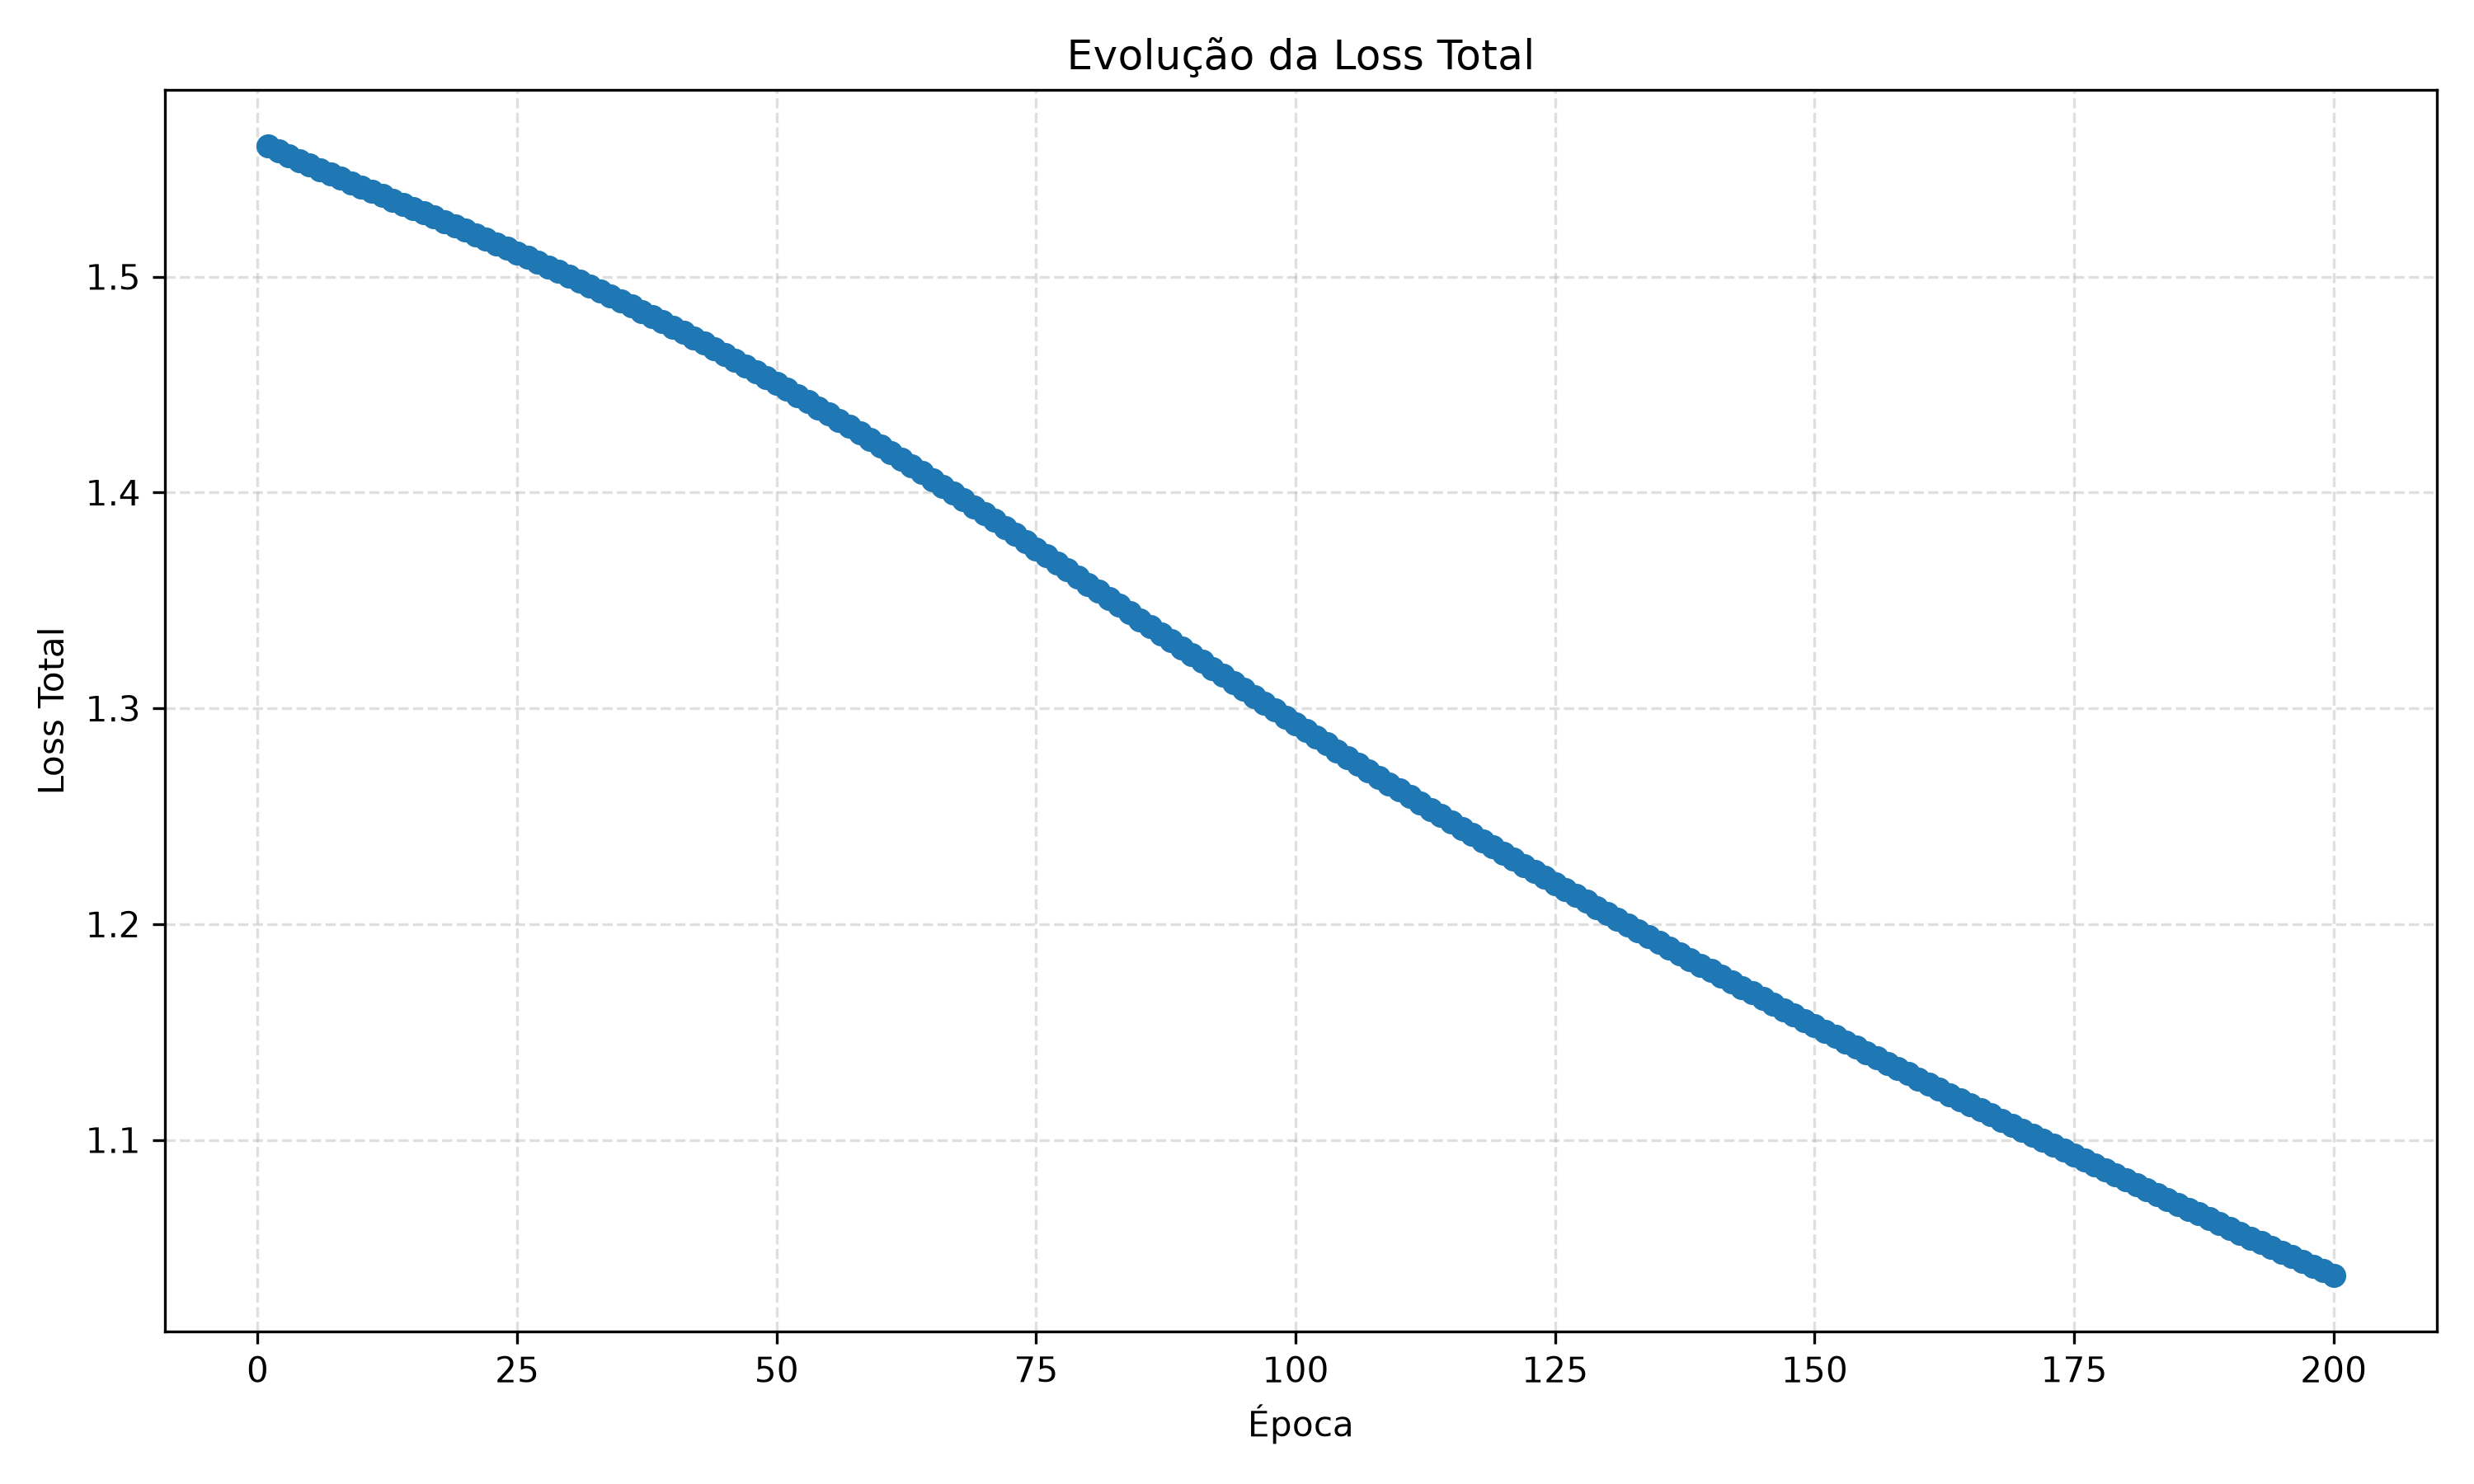

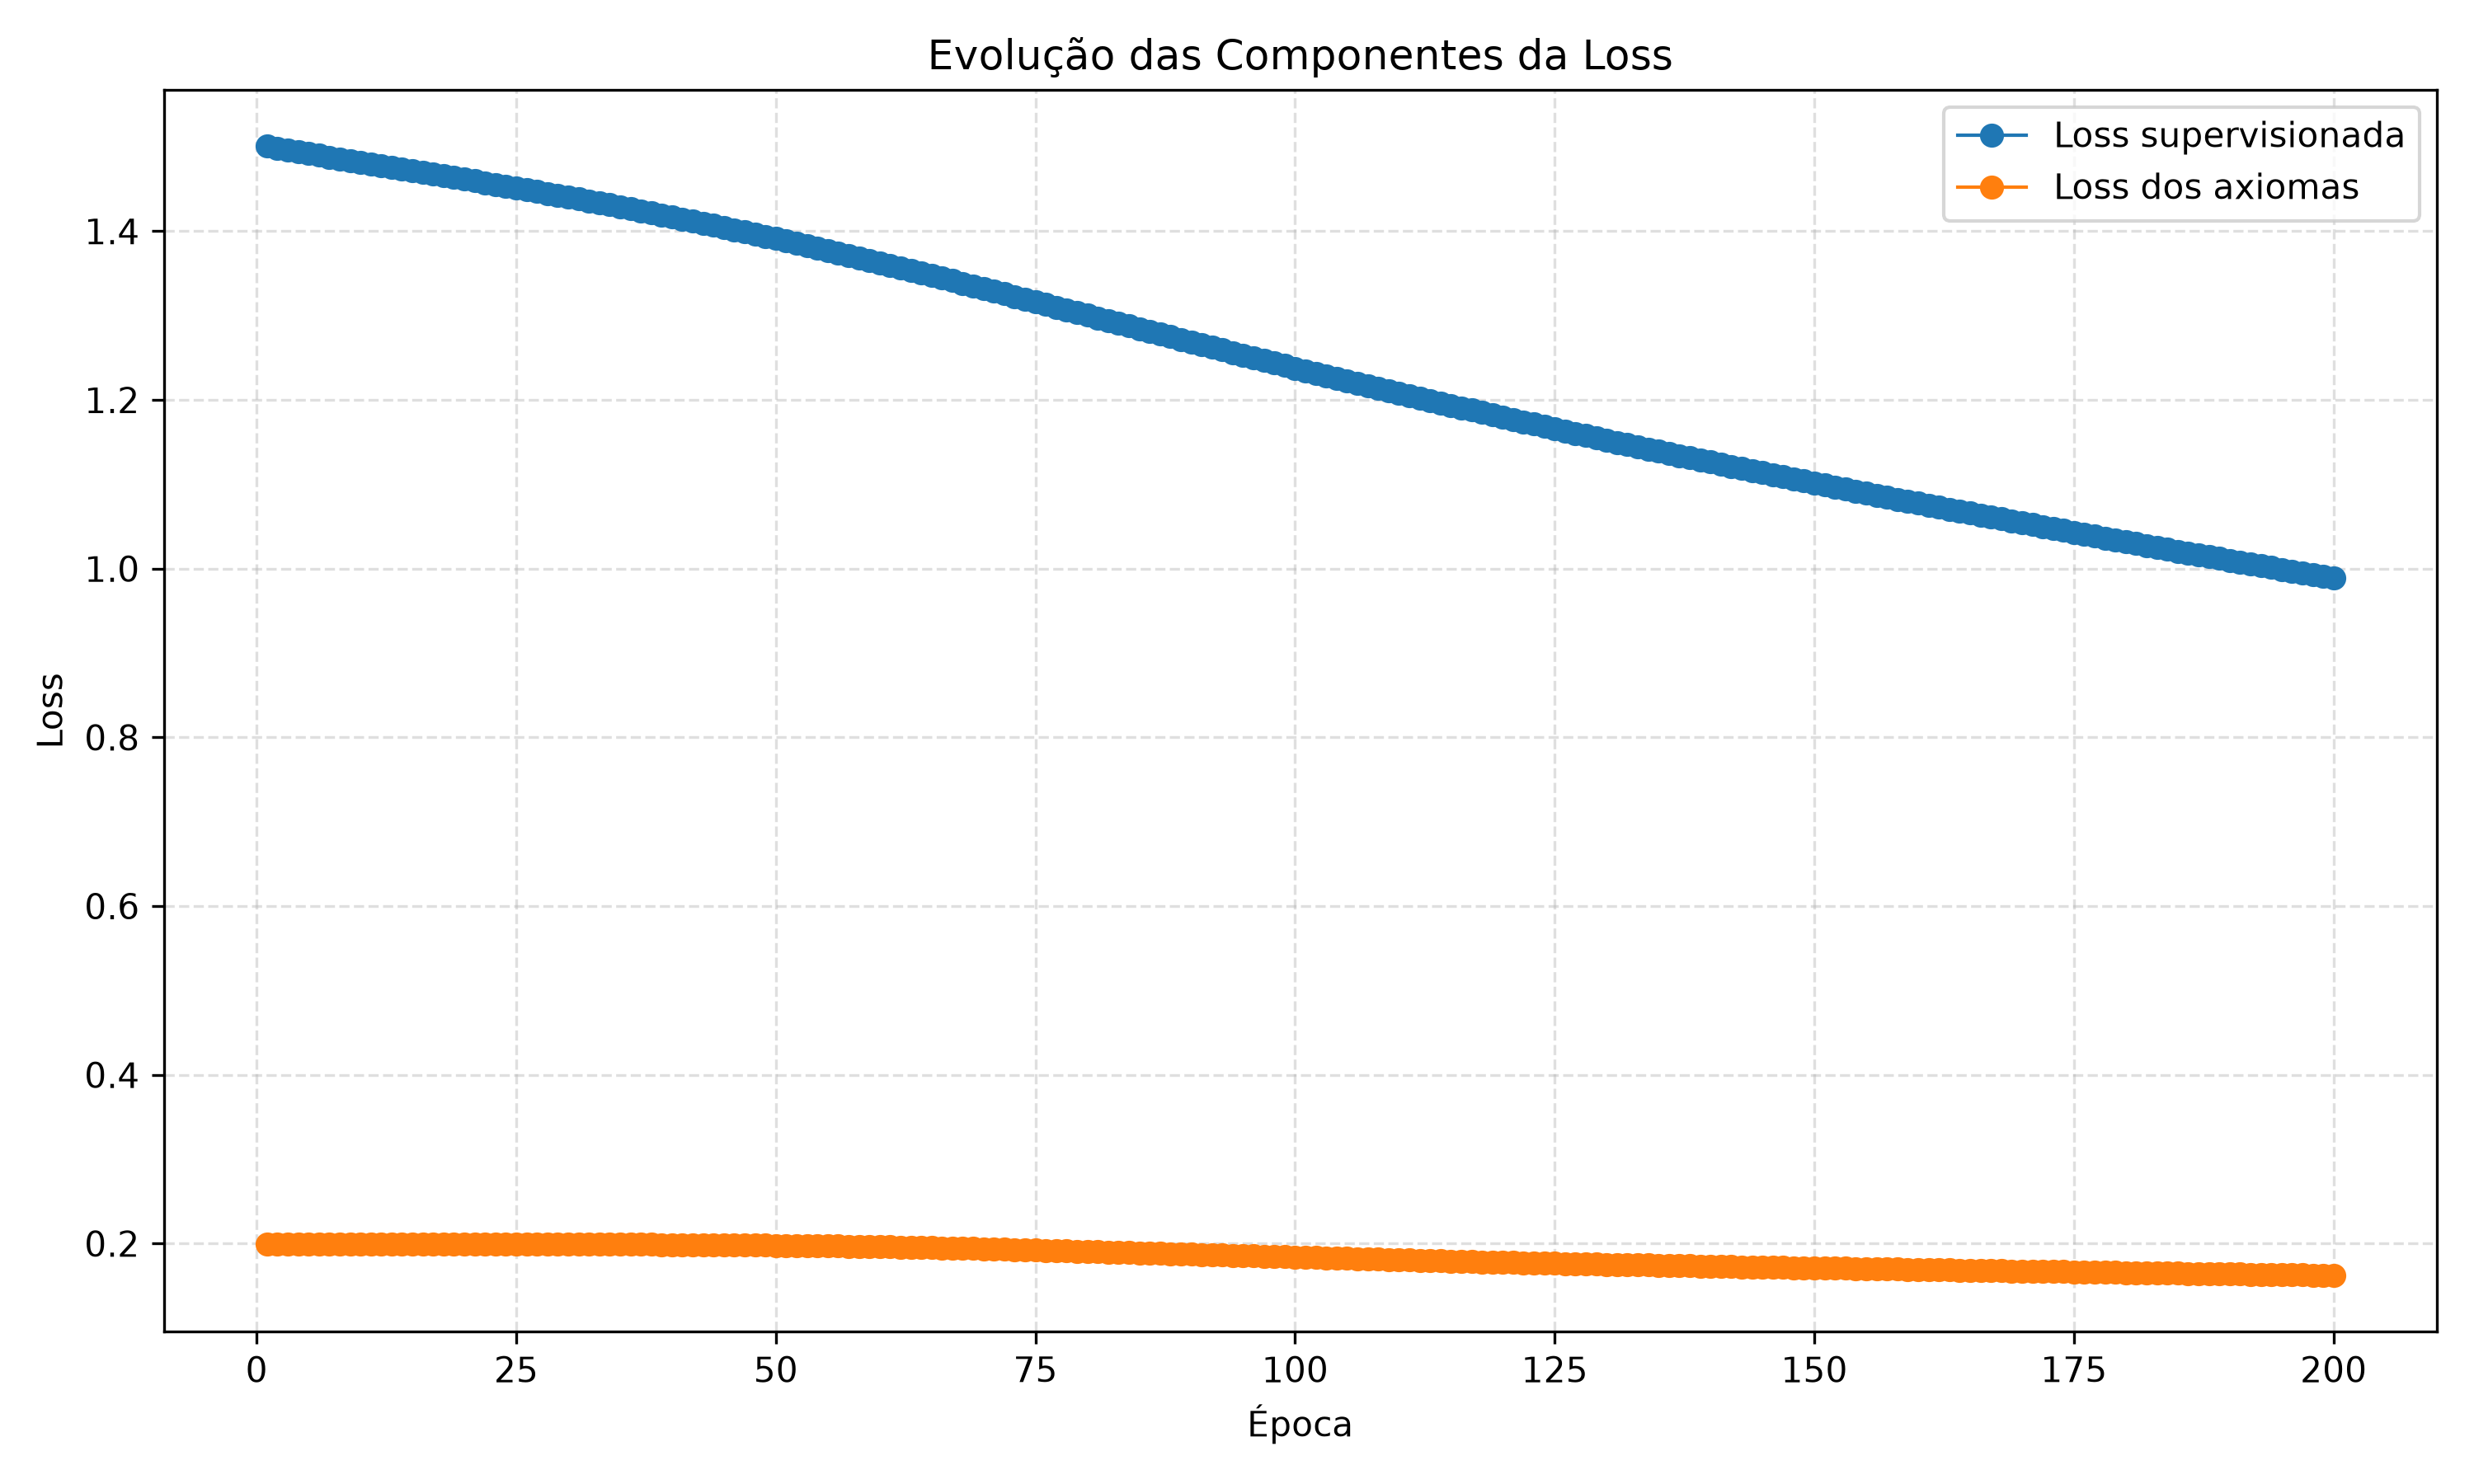

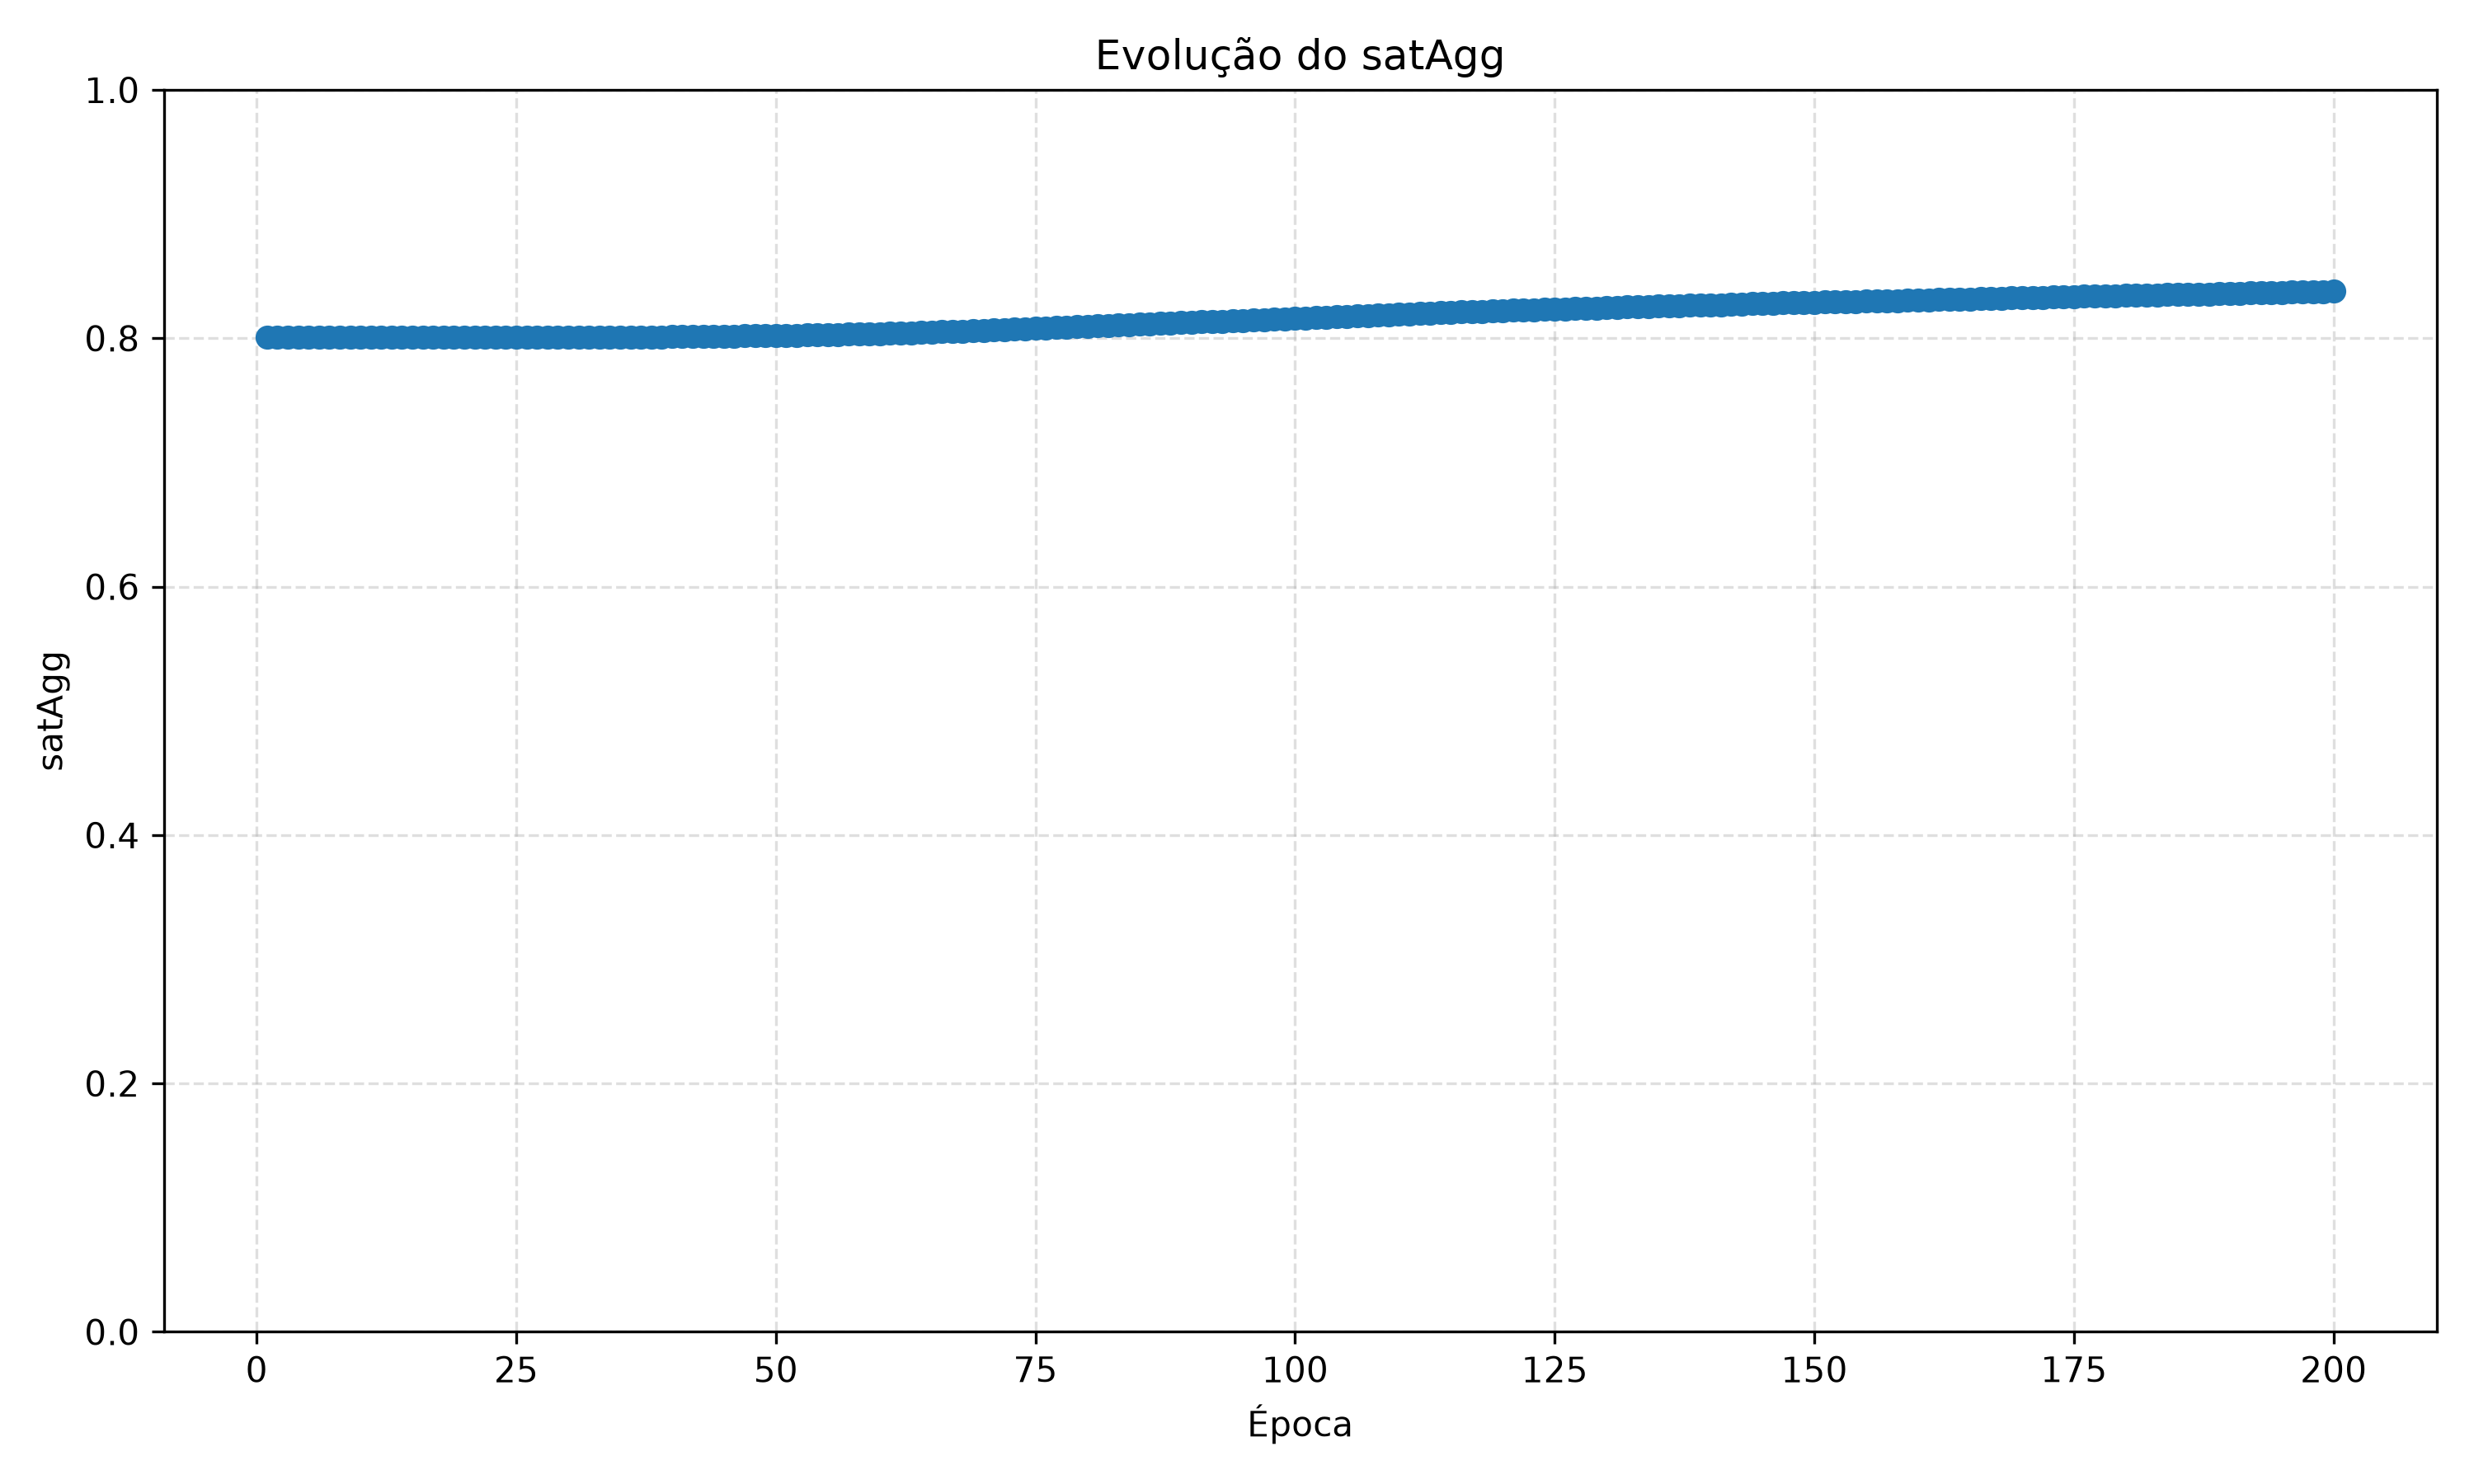

In [3]:
display(Image(filename=str(METRICS_DIR / "plots" / "loss_total.png")))
display(Image(filename=str(METRICS_DIR / "plots" / "losses_componentes.png")))
display(Image(filename=str(METRICS_DIR / "plots" / "satagg.png")))

## Balanceamento das relações

,relacao,total,positivos,negativos,proporcao_positivos,proporcao_negativos
0,leftOf,625,300,325,0.4800,0.5200
1,rightOf,625,300,325,0.4800,0.5200
2,below,625,300,325,0.4800,0.5200
3,above,625,300,325,0.4800,0.5200
4,closeTo,625,102,523,0.1632,0.8368
5,canStack,625,116,509,0.1856,0.8144


,relacao,total,positivos,negativos,proporcao_positivos,proporcao_negativos
0,inBetween,13800,7556,6244,0.547536,0.452464


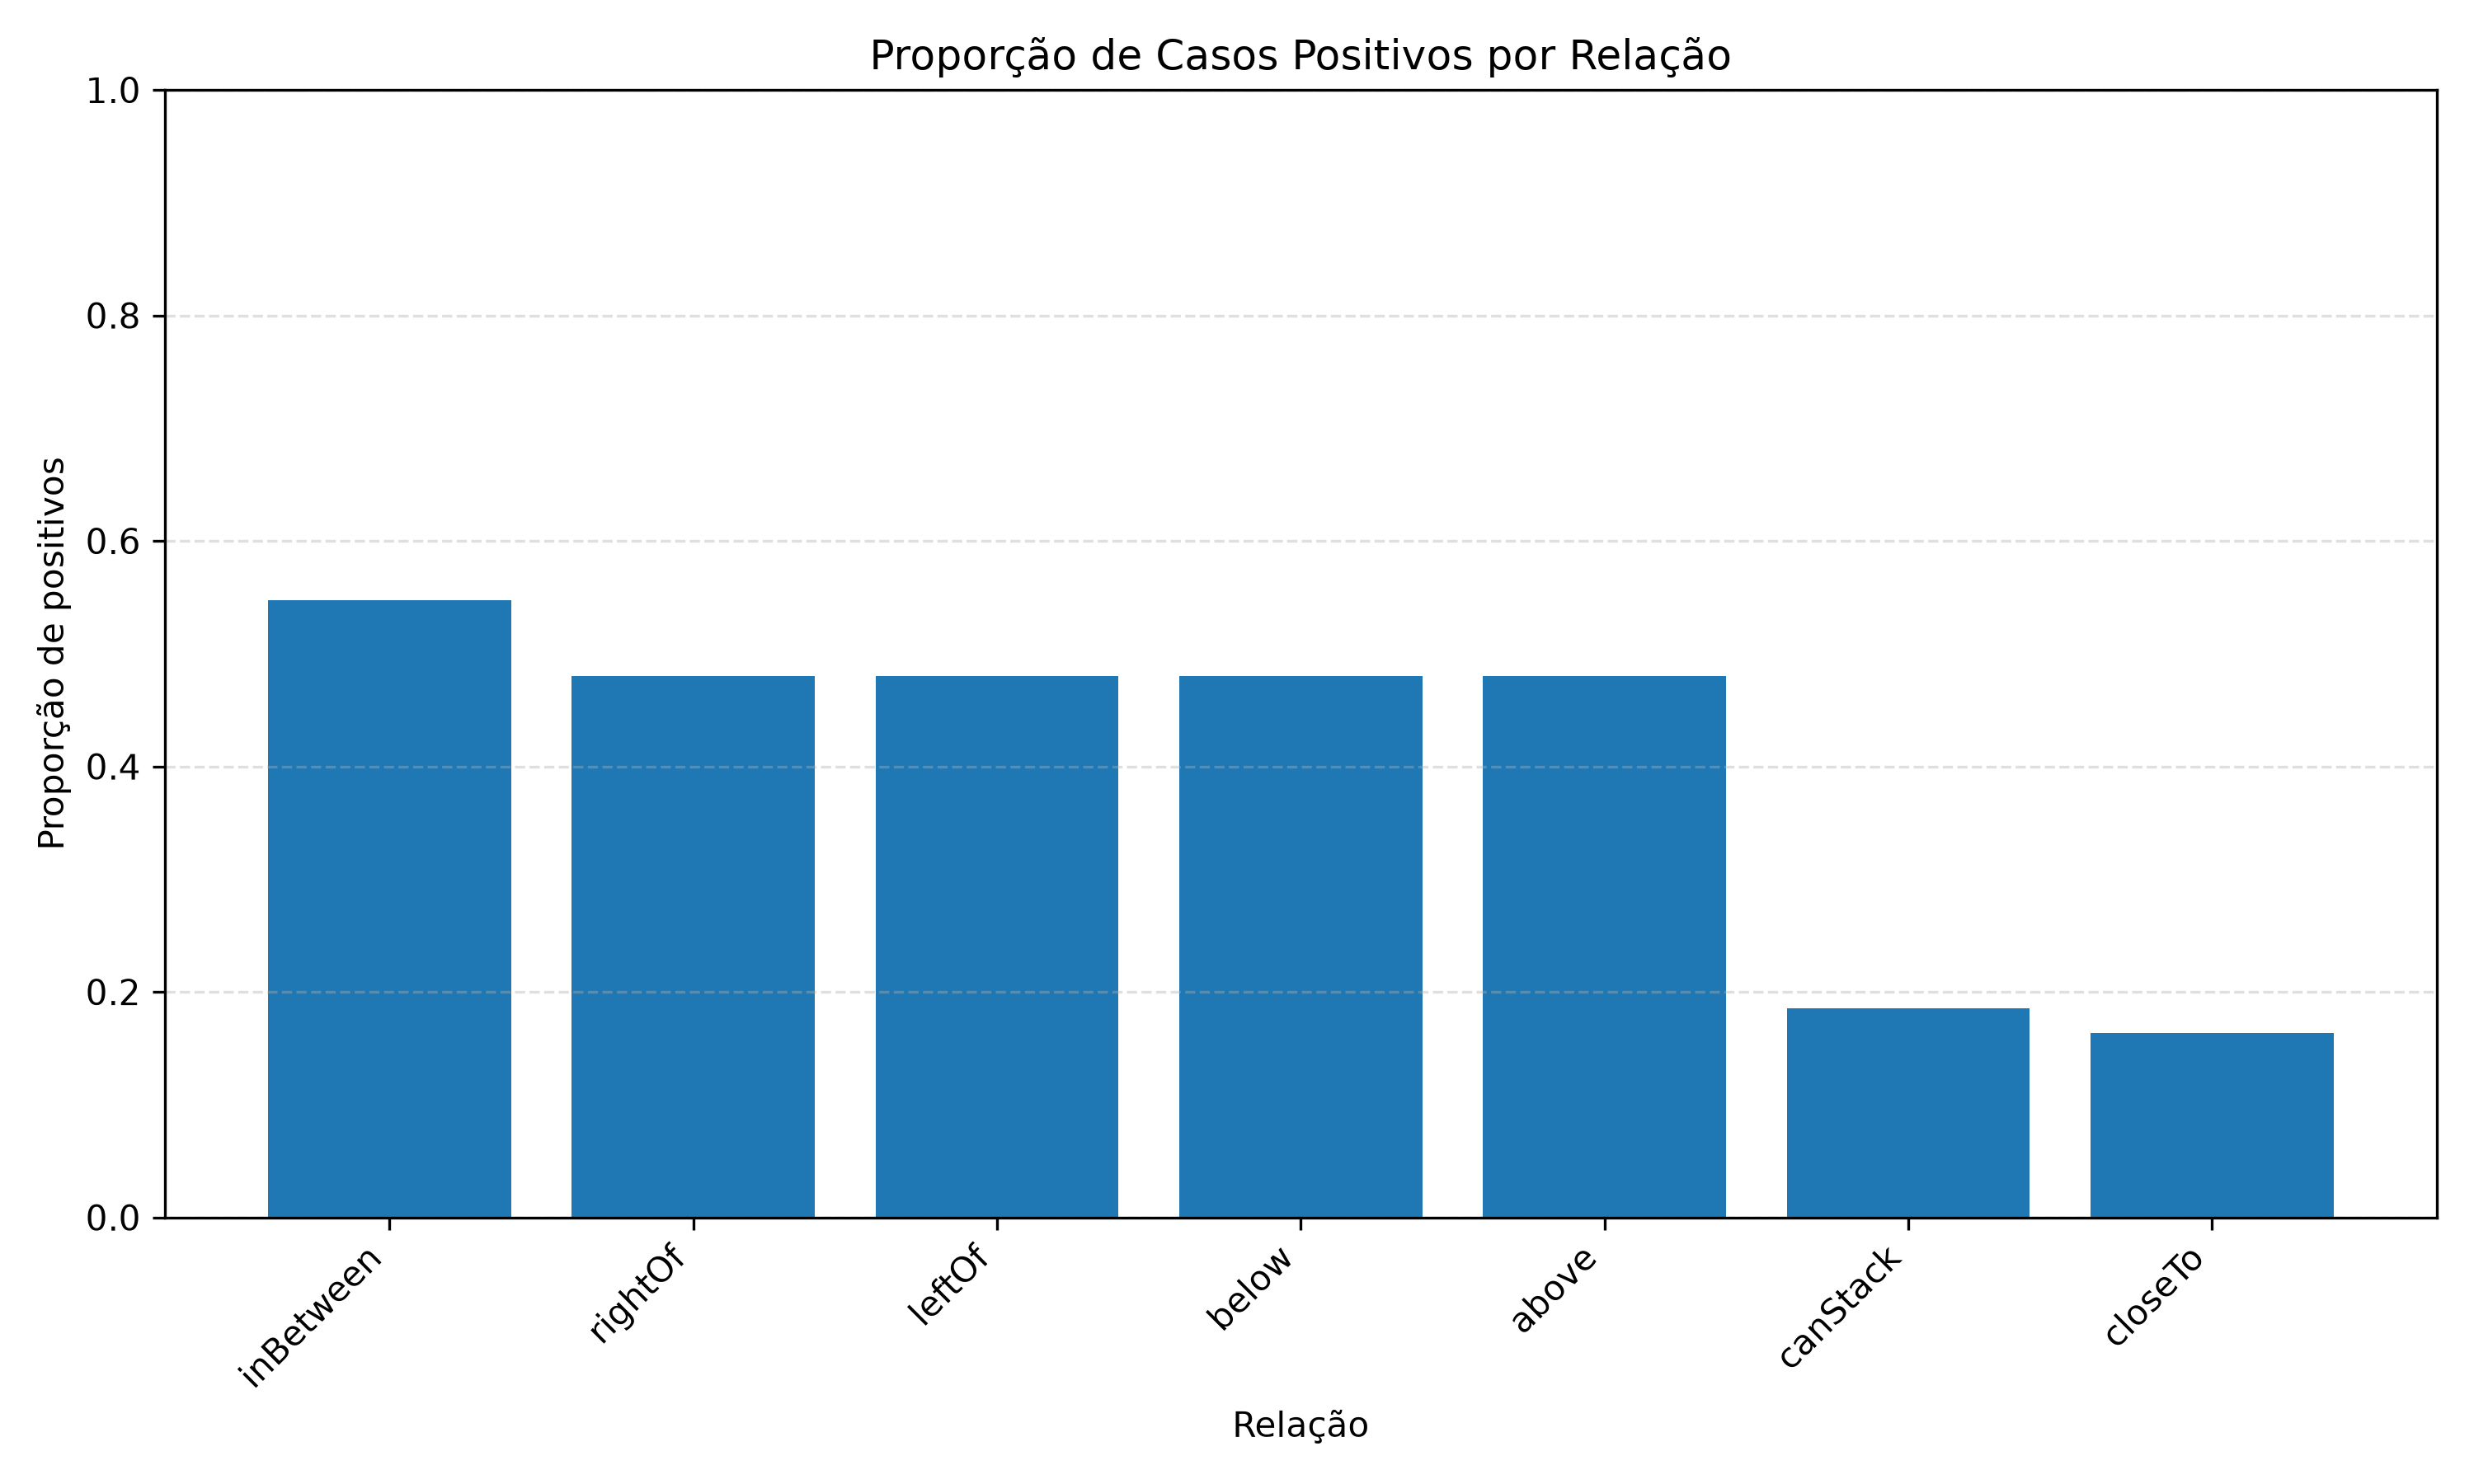

In [4]:
display(pd.read_csv(METRICS_DIR / "balanceamento_relacoes_binarias.csv"))
display(pd.read_csv(METRICS_DIR / "balanceamento_relacoes_ternarias.csv"))
display(Image(filename=str(METRICS_DIR / "plots" / "proporcao_positivos_por_relacao.png")))

## Satisfatibilidade individual dos axiomas

In [5]:
pd.read_csv(METRICS_DIR / "sat_individual_final.csv")

,axioma,satisfatibilidade
0,below_irreflexividade,0.573941
1,above_irreflexividade,0.574872
2,left_irreflexividade,0.586028
3,right_irreflexividade,0.587454
4,inbetween_implica_configuracao_espacial,0.761661
5,above_implica_below_inverso,0.797160
6,below_implica_above_inverso,0.808872
7,can_stack_implica_above,0.814417
8,left_implica_right_inverso,0.822370
9,right_implica_left_inverso,0.826675


## Resumo diagnóstico completo

In [6]:
caminho_diagnostico = METRICS_DIR / "resumo_diagnostico.md"
display(Markdown(caminho_diagnostico.read_text(encoding="utf-8")))

# Resumo diagnóstico do treinamento LTN

## 1. Visão geral

Este arquivo resume a análise do treinamento realizado com os predicados LTN treináveis.
O objetivo é verificar se o modelo está aprendendo as relações espaciais e se há problemas de desbalanceamento.

## 2. Evolução geral do treinamento

- Loss total inicial: `1.5604`
- Loss total final: `1.0372`
- satAgg inicial: `0.8007`
- satAgg final: `0.8378`

A loss total diminuiu ao longo do treinamento, indicando que o modelo reduziu o erro global.
O satAgg aumentou, indicando que a base de conhecimento ficou mais satisfeita ao final do treinamento.

## 3. Balanceamento das relações

### Relações binárias

| relacao   |   total |   positivos |   negativos |   proporcao_positivos |   proporcao_negativos |
|:----------|--------:|------------:|------------:|----------------------:|----------------------:|
| leftOf    |     625 |         300 |         325 |                0.48   |                0.52   |
| rightOf   |     625 |         300 |         325 |                0.48   |                0.52   |
| below     |     625 |         300 |         325 |                0.48   |                0.52   |
| above     |     625 |         300 |         325 |                0.48   |                0.52   |
| closeTo   |     625 |         102 |         523 |                0.1632 |                0.8368 |
| canStack  |     625 |         116 |         509 |                0.1856 |                0.8144 |

### Relações ternárias

| relacao   |   total |   positivos |   negativos |   proporcao_positivos |   proporcao_negativos |
|:----------|--------:|------------:|------------:|----------------------:|----------------------:|
| inBetween |   13800 |        7556 |        6244 |              0.547536 |              0.452464 |

## 4. Métricas finais

As fórmulas das métricas clássicas utilizadas nesta avaliação estão documentadas em: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\metricas_classicas.md`.

### Predicados binários

| relacao   |   accuracy |   precision |   recall |       f1 |   best_threshold |   best_accuracy |   best_precision |   best_recall |   best_f1 |
|:----------|-----------:|------------:|---------:|---------:|-----------------:|----------------:|-----------------:|--------------:|----------:|
| leftOf    |      0.848 |    0.833333 | 0.847458 | 0.840336 |             0.4  |           0.84  |         0.774648 |      0.932203 |  0.846154 |
| rightOf   |      0.856 |    0.90566  | 0.786885 | 0.842105 |             0.45 |           0.856 |         0.890909 |      0.803279 |  0.844828 |
| below     |      0.816 |    0.847826 | 0.709091 | 0.772277 |             0.4  |           0.792 |         0.716418 |      0.872727 |  0.786885 |
| above     |      0.832 |    0.87931  | 0.784615 | 0.829268 |             0.45 |           0.848 |         0.838235 |      0.876923 |  0.857143 |
| closeTo   |      1     |    1        | 1        | 1        |             0.45 |           1     |         1        |      1        |  1        |
| canStack  |      0.784 |    0.510638 | 0.857143 | 0.64     |             0.5  |           0.784 |         0.510638 |      0.857143 |  0.64     |

### Predicados ternários

| relacao   |   accuracy |   precision |   recall |       f1 |   best_threshold |   best_accuracy |   best_precision |   best_recall |   best_f1 |
|:----------|-----------:|------------:|---------:|---------:|-----------------:|----------------:|-----------------:|--------------:|----------:|
| inBetween |   0.722101 |    0.692478 | 0.855776 | 0.765515 |              0.5 |        0.722101 |         0.692478 |      0.855776 |  0.765515 |

## 5. Diagnóstico específico

- F1 de `closeTo`: `1.0000`
  - Positivos em `closeTo`: `102`
  - Negativos em `closeTo`: `523`
  - Proporção de positivos em `closeTo`: `0.1632`
  - Diagnóstico: o predicado `closeTo` está com desempenho excelente.
  - Interpretação: isso é esperado quando `closeTo` é tratado como predicado fuzzy determinístico baseado em distância.

- F1 de `canStack`: `0.6400`
  - Positivos em `canStack`: `116`
  - Negativos em `canStack`: `509`
  - Proporção de positivos em `canStack`: `0.1856`
  - Diagnóstico: `canStack` apresentou desempenho intermediário ou bom para uma relação composta.
  - Interpretação: como `canStack` depende de múltiplas condições espaciais e semânticas, é esperado que seja mais difícil que relações simples.

- F1 de `inBetween`: `0.7655`
  - Diagnóstico: por ser uma relação ternária, é esperado que seja mais difícil que leftOf/rightOf.

## 6. Axiomas com menor satisfatibilidade

| axioma                                  |   satisfatibilidade |
|:----------------------------------------|--------------------:|
| below_irreflexividade                   |            0.573941 |
| above_irreflexividade                   |            0.574872 |
| left_irreflexividade                    |            0.586028 |
| right_irreflexividade                   |            0.587454 |
| inbetween_implica_configuracao_espacial |            0.761661 |
| above_implica_below_inverso             |            0.79716  |
| below_implica_above_inverso             |            0.808872 |
| can_stack_implica_above                 |            0.814417 |
| left_implica_right_inverso              |            0.82237  |
| right_implica_left_inverso              |            0.826675 |

## 7. Arquivos gerados

### Tabelas

- `balanceamento_binario`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\balanceamento_relacoes_binarias.csv`
- `balanceamento_ternario`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\balanceamento_relacoes_ternarias.csv`
- `metricas_binarias`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\metricas_finais_binarias.csv`
- `metricas_ternarias`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\metricas_finais_ternarias.csv`
- `sat_individual`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\sat_individual_final.csv`

### Gráficos

- `loss_total`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\plots\loss_total.png`
- `losses_componentes`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\plots\losses_componentes.png`
- `satagg`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\plots\satagg.png`
- `f1_final`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\plots\f1_final_por_predicado.png`
- `balanceamento`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\plots\proporcao_positivos_por_relacao.png`

### Fórmulas das métricas

- `metricas_classicas`: `C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch\results\metrics\metricas_classicas.md`

## 8. Próximo passo recomendado

Com as métricas consolidadas em `results/metrics/`, o próximo módulo natural é `src/query_ltn.py`.

Esse módulo deve carregar o modelo treinado, executar consultas compostas e gerar explicações textuais para cada resposta.

As consultas principais devem incluir:

1. objeto pequeno abaixo de cilindro e à esquerda de quadrado;
2. cone verde entre dois objetos;
3. regra universal sobre triângulos próximos terem o mesmo tamanho;
4. existência de objeto que possa ser empilhado sobre outro.

Os resultados dessas consultas devem ser salvos em `results/queries/`.